In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/forestfires.csv')

In [4]:
print(df.shape)          
print(df.head(3))
print(df.dtypes)
print(df.isnull().sum()) 
print(df["area"].describe())

(517, 31)
  month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  ...  monthfeb  \
0   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0  ...         0   
1   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0  ...         0   
2   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0  ...         0   

   monthjan  monthjul  monthjun  monthmar  monthmay  monthnov  monthoct  \
0         0         0         0         1         0         0         0   
1         0         0         0         0         0         0         1   
2         0         0         0         0         0         0         1   

   monthsep  size_category  
0         0          small  
1         0          small  
2         0          small  

[3 rows x 31 columns]
month             object
day               object
FFMC             float64
DMC              float64
DC               float64
ISI              float64
temp             float64
RH                 int64
wind             float64
rain            

In [5]:
df.describe()

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,dayfri,...,monthdec,monthfeb,monthjan,monthjul,monthjun,monthmar,monthmay,monthnov,monthoct,monthsep
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,...,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292,0.164410,...,0.017408,0.038685,0.003868,0.061896,0.032882,0.104449,0.003868,0.001934,0.029014,0.332689
std,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818,0.371006,...,0.130913,0.193029,0.062137,0.241199,0.178500,0.306138,0.062137,0.043980,0.168007,0.471632
min,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
drop_cols = ["month", "day", "size_category"]
df_clean = df.drop(columns=drop_cols)

df_clean["log_area"] = np.log1p(df_clean["area"])

X = df_clean.drop(columns=["area", "log_area"]).values
y = df_clean["log_area"].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42)

print(X_train.shape)  
print(X_val.shape)   
print(X_test.shape)

(373, 27)
(66, 27)
(78, 27)


In [8]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)  
X_val_s   = scaler.transform(X_val)        
X_test_s  = scaler.transform(X_test)      

print('Before scaling — ')
print(X_train[:, 0].mean()) 
print(X_train[:, 0].std())  

print('After scaling —')
print(X_train_s[:, 0].mean()) 
print(X_train_s[:, 0].std())  

Before scaling — 
90.51635388739946
5.910555432972289
After scaling —
4.0003746517324677e-16
1.0000000000000002


In [14]:
model = keras.Sequential([
    layers.Input(shape=(27,), name="Input"),
    layers.Dense(128, activation="relu", name="Dense_1"),
    layers.BatchNormalization(),   
    layers.Dropout(0.3),          
    layers.Dense(64, activation="relu", name="Dense_2"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu", name="Dense_3"),
    layers.Dense(1, activation="linear", name="Output"),

], name="ForestFire_NN")
model.summary() 

Model: "ForestFire_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                 │ (None, 128)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [15]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "mse",    
    metrics   = ["mae"]  
)

In [16]:
early_stop = callbacks.EarlyStopping(
    monitor             = "val_loss",
    patience            = 30,
    restore_best_weights = True,   
    verbose             = 1
)


reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,      
    patience = 10,
    min_lr   = 1e-6,
    verbose  = 1
)

In [17]:
history = model.fit(
    X_train_s, y_train,          
    validation_data = (X_val_s, y_val),  
    epochs     = 300,             
    batch_size = 32,             
    callbacks  = [early_stop, reduce_lr],
    verbose    = 1                
)

actual = len(history.history["loss"])
print(f"Stopped at epoch {actual}")  

Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.7142 - mae: 1.6153 - val_loss: 2.4775 - val_mae: 1.1436 - learning_rate: 0.0010
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.5782 - mae: 1.2576 - val_loss: 2.1530 - val_mae: 1.0997 - learning_rate: 0.0010
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3795 - mae: 1.2057 - val_loss: 2.2224 - val_mae: 1.1091 - learning_rate: 0.0010
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1113 - mae: 1.1522 - val_loss: 2.2715 - val_mae: 1.1125 - learning_rate: 0.0010
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0696 - mae: 1.1222 - val_loss: 2.2236 - val_mae: 1.1038 - learning_rate: 0.0010
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0579 - mae: 1.1187 - val_loss: 2.1598 - val_mae: 1.0961 - learning_rate: 0.0010
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1272 - mae: 1.1751 - val_loss: 2.1455 - val_mae: 1.0992 - learning_rate: 0.0010
Epoch 8/300


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
RMSE (log): 1.648
R²        : -0.211
RMSE (ha) : 126.61 hectares


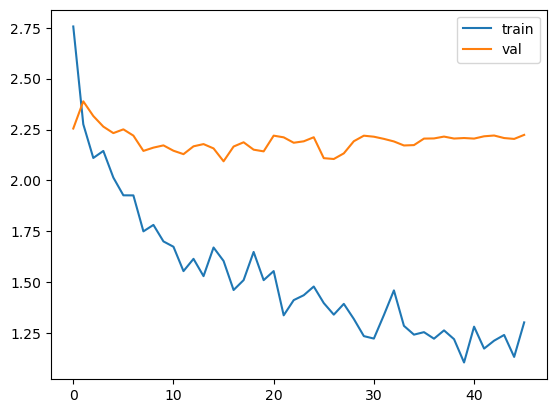

In [13]:
y_pred_log = model.predict(X_test_s).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2   = r2_score(y_test, y_pred_log)
print(f"RMSE (log): {rmse:.3f}")
print(f"R²        : {r2:.3f}")

y_pred_ha = np.expm1(y_pred_log)
y_test_ha = np.expm1(y_test)

rmse_ha = np.sqrt(mean_squared_error(y_test_ha, y_pred_ha))
print(f"RMSE (ha) : {rmse_ha:.2f} hectares")

import matplotlib.pyplot as plt
plt.plot(history.history["loss"],     label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend(); plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/forestfires.csv')

print(df.shape)          
print(df.head(3))
print(df.dtypes)
print(df.isnull().sum()) 
print(df["area"].describe())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42)

print(X_train.shape)  
print(X_val.shape)   
print(X_test.shape)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)  
X_val_s   = scaler.transform(X_val)        
X_test_s  = scaler.transform(X_test)      

print('Before scaling — ')
print(X_train[:, 0].mean()) 
print(X_train[:, 0].std())  

print('After scaling —')
print(X_train_s[:, 0].mean()) 
print(X_train_s[:, 0].std()) 

model = keras.Sequential([
    layers.Input(shape=(27,), name="Input"),
    layers.Dense(128, activation="relu", name="Dense_1"),
    layers.BatchNormalization(),   
    layers.Dropout(0.3),          
    layers.Dense(64, activation="relu", name="Dense_2"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu", name="Dense_3"),
    layers.Dense(1, activation="linear", name="Output"),

], name="ForestFire_NN")
model.summary() 

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "mse",    
    metrics   = ["mae"]  
)

early_stop = callbacks.EarlyStopping(
    monitor             = "val_loss",
    patience            = 30,
    restore_best_weights = True,   
    verbose             = 1
)


reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,      
    patience = 10,
    min_lr   = 1e-6,
    verbose  = 1
)

history = model.fit(
    X_train_s, y_train,          
    validation_data = (X_val_s, y_val),  
    epochs     = 300,             
    batch_size = 32,             
    callbacks  = [early_stop, reduce_lr],
    verbose    = 1                
)

actual = len(history.history["loss"])
print(f"Stopped at epoch {actual}")  

y_pred_log = model.predict(X_test_s).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2   = r2_score(y_test, y_pred_log)
print(f"RMSE (log): {rmse:.3f}")
print(f"R²        : {r2:.3f}")

y_pred_ha = np.expm1(y_pred_log)
y_test_ha = np.expm1(y_test)

rmse_ha = np.sqrt(mean_squared_error(y_test_ha, y_pred_ha))
print(f"RMSE (ha) : {rmse_ha:.2f} hectares")

import matplotlib.pyplot as plt
plt.plot(history.history["loss"],     label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend(); plt.show()

# Forest Fire Prediction — Summary

This project uses a Keras-based neural network to predict the burned area of forest fires using environmental data such as temperature, humidity, wind, and rainfall.

The dataset was preprocessed by handling features and applying standard scaling to improve model performance. The target variable was log-transformed to handle skewness and make predictions more stable.

A neural network with multiple layers was built using ReLU activation, along with Batch Normalization and Dropout to improve learning and reduce overfitting. The model was trained using early stopping and learning rate reduction to ensure efficient training.

The model achieved reasonable performance, capturing general patterns between environmental conditions and fire size. However, predicting large fires remains difficult due to the unpredictable nature of real-world events.

Overall, the model demonstrates that deep learning can be used to estimate forest fire risk, though further improvements can be made with more data and advanced techniques.
